# Workshop Solutions: Training a GAN on MNIST

This is a fully worked version of the GAN workshop notebook.


In [1]:
# Core imports
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load and inspect the data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

len(train_dataset)

100.0%
100.0%
100.0%
100.0%


60000

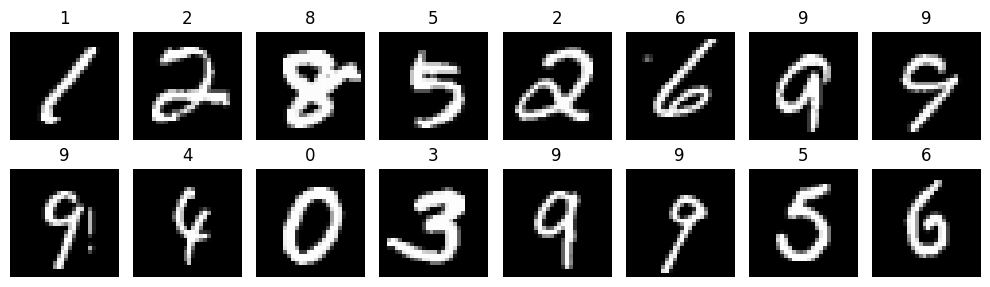

In [3]:
real_batch, real_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, label in zip(axes.flatten(), real_batch[:16], real_labels[:16]):
    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.set_title(str(label.item()))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Define the Generator and Discriminator

In [4]:
latent_dim = 100
image_dim = 28 * 28

In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_dim=784):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, image_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self, image_dim=784):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [6]:
G = Generator(latent_dim=latent_dim, image_dim=image_dim).to(device)
D = Discriminator(image_dim=image_dim).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 3. Loss function and optimizers

In [7]:
criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

## 4. Helper function to visualize generated samples

In [8]:
@torch.no_grad()
def show_generated_samples(generator, latent_dim=100, n=16):
    generator.eval()
    z = torch.randn(n, latent_dim, device=device)
    fake_images = generator(z).cpu()

    fake_images = (fake_images + 1) / 2

    grid = utils.make_grid(fake_images, nrow=4)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()
    generator.train()

## 5. One GAN training step

In [9]:
def train_discriminator_step(real_images):
    batch_size = real_images.size(0)
    real_images = real_images.to(device)

    d_optimizer.zero_grad()

    z = torch.randn(batch_size, latent_dim, device=device)
    fake_images = G(z).detach()

    real_targets = torch.ones(batch_size, 1, device=device)
    fake_targets = torch.zeros(batch_size, 1, device=device)

    real_preds = D(real_images)
    fake_preds = D(fake_images)

    real_loss = criterion(real_preds, real_targets)
    fake_loss = criterion(fake_preds, fake_targets)
    d_loss = real_loss + fake_loss

    d_loss.backward()
    d_optimizer.step()

    return d_loss.item()

In [10]:
def train_generator_step(batch_size):
    g_optimizer.zero_grad()

    z = torch.randn(batch_size, latent_dim, device=device)
    fake_images = G(z)

    targets = torch.ones(batch_size, 1, device=device)
    preds = D(fake_images)

    g_loss = criterion(preds, targets)

    g_loss.backward()
    g_optimizer.step()

    return g_loss.item()

## 6. Full training loop

Epoch 01/10 | D loss: 0.8331 | G loss: 1.4938
Epoch 02/10 | D loss: 0.4437 | G loss: 3.3833


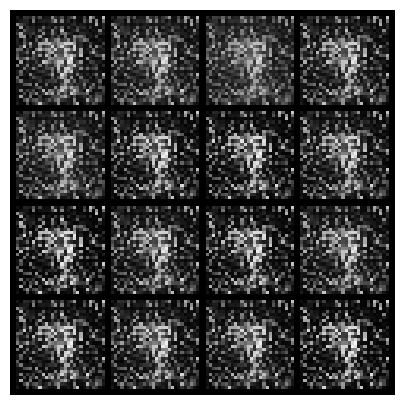

Epoch 03/10 | D loss: 0.3510 | G loss: 4.4326
Epoch 04/10 | D loss: 0.3143 | G loss: 4.6829


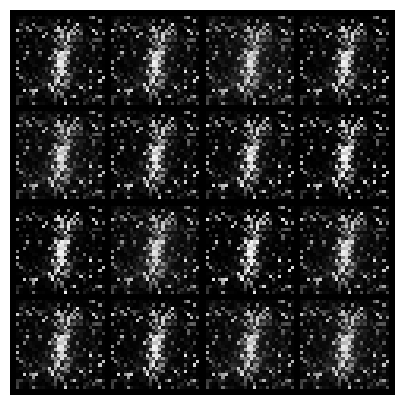

Epoch 05/10 | D loss: 0.2905 | G loss: 4.2997
Epoch 06/10 | D loss: 0.2468 | G loss: 5.0841


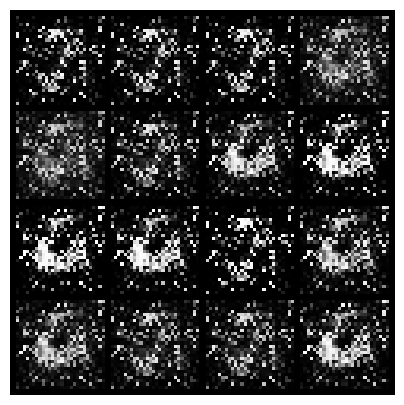

Epoch 07/10 | D loss: 0.3124 | G loss: 4.5256
Epoch 08/10 | D loss: 0.2727 | G loss: 4.3011


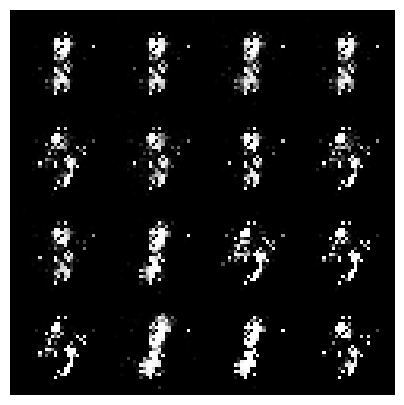

Epoch 09/10 | D loss: 0.1284 | G loss: 5.4979
Epoch 10/10 | D loss: 0.0006 | G loss: 8.3962


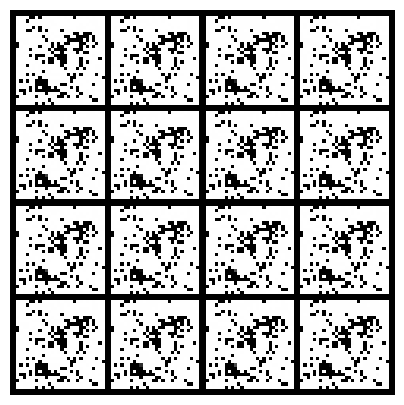

In [11]:
num_epochs = 10

g_losses = []
d_losses = []

for epoch in range(num_epochs):
    g_running = 0.0
    d_running = 0.0

    for real_images, _ in train_loader:
        d_loss = train_discriminator_step(real_images)
        g_loss = train_generator_step(real_images.size(0))

        d_running += d_loss
        g_running += g_loss

    avg_d = d_running / len(train_loader)
    avg_g = g_running / len(train_loader)

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | D loss: {avg_d:.4f} | G loss: {avg_g:.4f}")

    if (epoch + 1) % 2 == 0:
        show_generated_samples(G, latent_dim=latent_dim, n=16)

## 7. Plot the learning curves

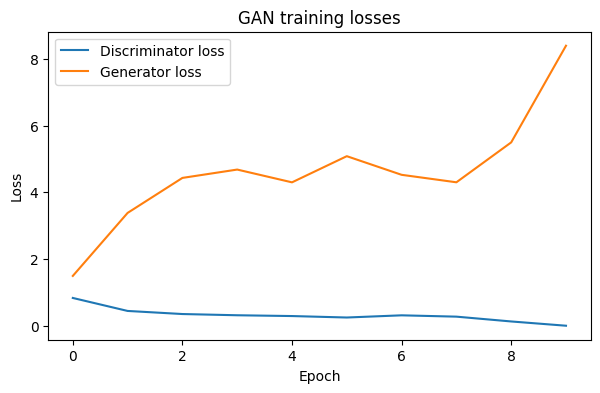

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(d_losses, label="Discriminator loss")
plt.plot(g_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training losses")
plt.legend()
plt.show()